# MVP Engenharia de Dados

Criar Estrutura do Projeto

In [0]:
%sql

CREATE CATALOG IF NOT EXISTS mvp_eng_dados;

CREATE SCHEMA IF NOT EXISTS mvp_eng_dados.staging;
CREATE SCHEMA IF NOT EXISTS mvp_eng_dados.bronze;
CREATE SCHEMA IF NOT EXISTS mvp_eng_dados.silver;
CREATE SCHEMA IF NOT EXISTS mvp_eng_dados.gold;

CREATE VOLUME IF NOT EXISTS mvp_eng_dados.staging.gold_price_data;

Instalar KaggleHub

In [0]:
%pip install kagglehub

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Reinicar Python

In [0]:
%restart_python

Baixar o dataset do Kaggle e colocá-lo no Volume de Staging

In [0]:
import kagglehub
import os
import shutil

# Download do dataset do Kaggle
path = kagglehub.dataset_download(
    "bhushandivekar/gold-price-2005-2026-historical-price-data"
)

print("Dataset baixado em:")
print(path)

print("\nArquivos encontrados:")
print(os.listdir(path))

Dataset baixado em:
/home/spark-aca1db52-dc3e-4e5f-90c2-8a/.cache/kagglehub/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data/versions/1

Arquivos encontrados:
['Gold Futures Historical Data.csv']


In [0]:
import os
import shutil

# Caminho do arquivo baixado pelo Kaggle
source_file = os.path.join(
    path,
    "Gold Futures Historical Data.csv"
)

# Volume de Staging
staging_path = "/Volumes/mvp_eng_dados/staging/gold_price_data"

# Garante que o diretório existe
os.makedirs(staging_path, exist_ok=True)

# Copia o arquivo original para o Staging
destination_file = os.path.join(
    staging_path,
    "Gold Futures Historical Data.csv"
)

shutil.copy2(source_file, destination_file)

print("Arquivo copiado com sucesso!")
print(f"Origem: {source_file}")
print(f"Destino: {destination_file}")

Arquivo copiado com sucesso!
Origem: /home/spark-aca1db52-dc3e-4e5f-90c2-8a/.cache/kagglehub/datasets/bhushandivekar/gold-price-2005-2026-historical-price-data/versions/1/Gold Futures Historical Data.csv
Destino: /Volumes/mvp_eng_dados/staging/gold_price_data/Gold Futures Historical Data.csv


Verificar o arquivo no Staging

In [0]:
staging_file = "/Volumes/mvp_eng_dados/staging/gold_price_data/Gold Futures Historical Data.csv"

df_staging = (
    spark.read
    .option("header", True)
    .option("inferSchema", False)
    .csv(staging_file)
)

print(f"Quantidade de registros: {df_staging.count()}")
print(f"Quantidade de colunas: {len(df_staging.columns)}")
print("\nColunas:")
print(df_staging.columns)

display(df_staging.limit(10))

Quantidade de registros: 4997
Quantidade de colunas: 7

Colunas:
['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


Date,Price,Open,High,Low,Vol.,Change %
01-03-2005,429.7,438.9,438.9,427.8,82850,-1.98
01-04-2005,429.2,430.4,431.3,424.8,54830,-0.12
01-05-2005,427.3,429,429.3,425.9,43720,-0.44
01-06-2005,421.6,427,428.3,421.1,65180,-1.33
01-07-2005,419.5,422.1,425.8,417.2,97970,-0.5
01-10-2005,419.7,419.9,422.3,418.4,34180,0.05
01-11-2005,422.4,419.6,423.3,419.6,46900,0.64
01-12-2005,426.6,423,428.3,421.1,64040,0.99
01/13/2005,425.1,426.6,427.3,423.6,35090,-0.35
01/14/2005,423.3,422.9,423.3,422.7,30930,-0.42


Criar Tabela Bronze — Persistência dos Dados Brutos

In [0]:
from pyspark.sql.functions import current_timestamp, lit

df_bronze = (
    df_staging
    .toDF(
        "date_raw",
        "price_raw",
        "open_raw",
        "high_raw",
        "low_raw",
        "volume_raw",
        "change_pct_raw"
    )
    .withColumn("_ingestion_timestamp", current_timestamp())
    .withColumn(
        "_source",
        lit("Kaggle - Gold Futures Historical Data")
    )
)

bronze_table = "mvp_eng_dados.bronze.gold_price"

(
    df_bronze
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(bronze_table)
)

print(f"Tabela Bronze criada com sucesso: {bronze_table}")

Tabela Bronze criada com sucesso: mvp_eng_dados.bronze.gold_price


In [0]:
df_bronze_check = spark.table("mvp_eng_dados.bronze.gold_price")

print(f"Registros na Bronze: {df_bronze_check.count()}")
print(f"Quantidade de colunas: {len(df_bronze_check.columns)}")
print("\nColunas:")
print(df_bronze_check.columns)

display(df_bronze_check.limit(10))

Registros na Bronze: 4997
Quantidade de colunas: 9

Colunas:
['date_raw', 'price_raw', 'open_raw', 'high_raw', 'low_raw', 'volume_raw', 'change_pct_raw', '_ingestion_timestamp', '_source']


date_raw,price_raw,open_raw,high_raw,low_raw,volume_raw,change_pct_raw,_ingestion_timestamp,_source
01-03-2005,429.7,438.9,438.9,427.8,82850,-1.98,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-04-2005,429.2,430.4,431.3,424.8,54830,-0.12,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-05-2005,427.3,429,429.3,425.9,43720,-0.44,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-06-2005,421.6,427,428.3,421.1,65180,-1.33,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-07-2005,419.5,422.1,425.8,417.2,97970,-0.5,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-10-2005,419.7,419.9,422.3,418.4,34180,0.05,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-11-2005,422.4,419.6,423.3,419.6,46900,0.64,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01-12-2005,426.6,423,428.3,421.1,64040,0.99,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01/13/2005,425.1,426.6,427.3,423.6,35090,-0.35,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
01/14/2005,423.3,422.9,423.3,422.7,30930,-0.42,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data


Criar a Camada Silver — Padronização, Tipagem e Enriquecimento

In [0]:
from pyspark.sql.functions import (
    col,
    regexp_replace,
    try_to_date,
    year,
    month
)

df_bronze = spark.table("mvp_eng_dados.bronze.gold_price")

df_silver = (
    df_bronze
    .withColumn(
        "date",
        try_to_date(
            regexp_replace(col("date_raw"), "-", "/"),
            "MM/dd/yyyy"
        )
    )
    .withColumn(
        "price",
        regexp_replace(col("price_raw"), ",", "").cast("double")
    )
    .withColumn(
        "open_price",
        regexp_replace(col("open_raw"), ",", "").cast("double")
    )
    .withColumn(
        "high_price",
        regexp_replace(col("high_raw"), ",", "").cast("double")
    )
    .withColumn(
        "low_price",
        regexp_replace(col("low_raw"), ",", "").cast("double")
    )
    .withColumn(
        "volume",
        col("volume_raw").cast("long")
    )
    .withColumn(
        "change_pct",
        col("change_pct_raw").cast("double")
    )
    .withColumn("year", year(col("date")))
    .withColumn("month", month(col("date")))
    .select(
        "date",
        "year",
        "month",
        "price",
        "open_price",
        "high_price",
        "low_price",
        "volume",
        "change_pct",
        "_ingestion_timestamp",
        "_source"
    )
)

display(df_silver.limit(10))

date,year,month,price,open_price,high_price,low_price,volume,change_pct,_ingestion_timestamp,_source
2005-01-03,2005,1,429.7,438.9,438.9,427.8,82850,-1.98,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-04,2005,1,429.2,430.4,431.3,424.8,54830,-0.12,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-05,2005,1,427.3,429.0,429.3,425.9,43720,-0.44,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-06,2005,1,421.6,427.0,428.3,421.1,65180,-1.33,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-07,2005,1,419.5,422.1,425.8,417.2,97970,-0.5,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-10,2005,1,419.7,419.9,422.3,418.4,34180,0.05,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-11,2005,1,422.4,419.6,423.3,419.6,46900,0.64,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-12,2005,1,426.6,423.0,428.3,421.1,64040,0.99,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-13,2005,1,425.1,426.6,427.3,423.6,35090,-0.35,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data
2005-01-14,2005,1,423.3,422.9,423.3,422.7,30930,-0.42,2026-09-28T02:14:30.172Z,Kaggle - Gold Futures Historical Data


Salvar a Silver

In [0]:
silver_table = "mvp_eng_dados.silver.gold_price"

(
    df_silver
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(silver_table)
)

print(f"Tabela Silver atualizada com sucesso: {silver_table}")

Tabela Silver atualizada com sucesso: mvp_eng_dados.silver.gold_price


Validação da Qualidade dos Dados — Completude, Unicidade, Consistência e Valores Extremos

In [0]:
from pyspark.sql.functions import (
    col,
    count,
    sum,
    min,
    max,
    avg,
    when
)

df_quality = spark.table("mvp_eng_dados.silver.gold_price")

# 1. Completude: valores nulos
nulls = df_quality.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in df_quality.columns
])

print("=== 1. VALORES NULOS ===")
display(nulls)

# 2. Unicidade da data
total_records = df_quality.count()
distinct_dates = df_quality.select("date").distinct().count()

print("=== 2. UNICIDADE ===")
print(f"Total de registros: {total_records}")
print(f"Datas distintas: {distinct_dates}")
print(f"Registros duplicados por data: {total_records - distinct_dates}")

# 3. Consistência dos preços
invalid_prices = df_quality.filter(
    (col("low_price") > col("high_price")) |
    (col("open_price") < col("low_price")) |
    (col("open_price") > col("high_price")) |
    (col("price") < col("low_price")) |
    (col("price") > col("high_price"))
).count()

print("\n=== 3. CONSISTÊNCIA DOS PREÇOS ===")
print(f"Registros com relações de preço inválidas: {invalid_prices}")

# 4. Valores negativos
negative_values = df_quality.filter(
    (col("price") < 0) |
    (col("open_price") < 0) |
    (col("high_price") < 0) |
    (col("low_price") < 0) |
    (col("volume") < 0)
).count()

print("\n=== 4. VALORES NEGATIVOS ===")
print(f"Registros com valores negativos: {negative_values}")

# 5. Estatísticas básicas para identificação de extremos
print("\n=== 5. ESTATÍSTICAS BÁSICAS ===")

display(
    df_quality.select(
        min("date").alias("primeira_data"),
        max("date").alias("ultima_data"),
        min("price").alias("preco_minimo"),
        max("price").alias("preco_maximo"),
        avg("price").alias("preco_medio"),
        min("change_pct").alias("menor_variacao_pct"),
        max("change_pct").alias("maior_variacao_pct")
    )
)

=== 1. VALORES NULOS ===


date,year,month,price,open_price,high_price,low_price,volume,change_pct,_ingestion_timestamp,_source
0,0,0,0,0,0,0,0,0,0,0


=== 2. UNICIDADE ===
Total de registros: 4997
Datas distintas: 4997
Registros duplicados por data: 0

=== 3. CONSISTÊNCIA DOS PREÇOS ===
Registros com relações de preço inválidas: 4

=== 4. VALORES NEGATIVOS ===
Registros com valores negativos: 0

=== 5. ESTATÍSTICAS BÁSICAS ===


primeira_data,ultima_data,preco_minimo,preco_maximo,preco_medio,menor_variacao_pct,maior_variacao_pct
2005-01-03,2026-02-24,414.3,5354.8,1432.8253712227322,-11.39,8.97


Investigar os 4 registros inconsistentes

In [0]:
from pyspark.sql.functions import col

invalid_price_rows = df_quality.filter(
    (col("low_price") > col("high_price")) |
    (col("open_price") < col("low_price")) |
    (col("open_price") > col("high_price")) |
    (col("price") < col("low_price")) |
    (col("price") > col("high_price"))
).orderBy("date")

display(
    invalid_price_rows.select(
        "date",
        "open_price",
        "high_price",
        "low_price",
        "price",
        "volume",
        "change_pct"
    )
)

date,open_price,high_price,low_price,price,volume,change_pct
2020-04-09,1669.2,1739.7,1666.5,1739.9,1880,3.93
2021-12-02,1782.2,1782.5,1761.8,1761.6,930,-1.2
2021-12-23,1804.9,1810.8,1799.8,1811.0,770,0.53
2024-06-18,2323.3,2334.5,2309.1,2334.8,252690,0.77


In [0]:
from pyspark.sql.functions import (
    col,
    count,
    sum,
    min,
    max,
    avg,
    stddev,
    when
)

df_quality = spark.table("mvp_eng_dados.silver.gold_price")

# ============================================
# 1. COMPLETUDE
# ============================================

nulls = df_quality.select([
    sum(
        when(col(c).isNull(), 1).otherwise(0)
    ).alias(c)
    for c in df_quality.columns
])

print("=== 1. COMPLETUDE — VALORES NULOS ===")
display(nulls)


# ============================================
# 2. UNICIDADE
# ============================================

total_records = df_quality.count()
distinct_dates = df_quality.select("date").distinct().count()

print("=== 2. UNICIDADE ===")
print(f"Total de registros: {total_records}")
print(f"Datas distintas: {distinct_dates}")
print(f"Registros duplicados por data: {total_records - distinct_dates}")


# ============================================
# 3. CONSISTÊNCIA DOS PREÇOS
# ============================================

invalid_prices = df_quality.filter(
    (col("low_price") > col("high_price")) |
    (col("open_price") < col("low_price")) |
    (col("open_price") > col("high_price")) |
    (col("price") < col("low_price")) |
    (col("price") > col("high_price"))
).count()

print("\n=== 3. CONSISTÊNCIA DOS PREÇOS ===")
print(f"Registros com relações de preço inválidas: {invalid_prices}")


# ============================================
# 4. VALORES NEGATIVOS
# ============================================

negative_values = df_quality.filter(
    (col("price") < 0) |
    (col("open_price") < 0) |
    (col("high_price") < 0) |
    (col("low_price") < 0) |
    (col("volume") < 0)
).count()

print("\n=== 4. VALORES NEGATIVOS ===")
print(f"Registros com valores negativos: {negative_values}")


# ============================================
# 5. ESTATÍSTICAS BÁSICAS
# ============================================

print("\n=== 5. ESTATÍSTICAS BÁSICAS ===")

display(
    df_quality.select(
        min("date").alias("primeira_data"),
        max("date").alias("ultima_data"),
        min("price").alias("preco_minimo"),
        max("price").alias("preco_maximo"),
        avg("price").alias("preco_medio"),
        min("change_pct").alias("menor_variacao_pct"),
        max("change_pct").alias("maior_variacao_pct")
    )
)

=== 1. COMPLETUDE — VALORES NULOS ===


date,year,month,price,open_price,high_price,low_price,volume,change_pct,_ingestion_timestamp,_source
0,0,0,0,0,0,0,0,0,0,0


=== 2. UNICIDADE ===
Total de registros: 4997
Datas distintas: 4997
Registros duplicados por data: 0

=== 3. CONSISTÊNCIA DOS PREÇOS ===
Registros com relações de preço inválidas: 4

=== 4. VALORES NEGATIVOS ===
Registros com valores negativos: 0

=== 5. ESTATÍSTICAS BÁSICAS ===


primeira_data,ultima_data,preco_minimo,preco_maximo,preco_medio,menor_variacao_pct,maior_variacao_pct
2005-01-03,2026-02-24,414.3,5354.8,1432.8253712227322,-11.39,8.97


Camada Gold — Dados preparados para análise

A camada Gold contém dados preparados para consumo analítico.
Nesta etapa são calculados indicadores derivados, como retorno diário,
amplitude intradiária e indicadores consolidados por ano, permitindo
responder às perguntas de negócio definidas no projeto.

Gold Diária

In [0]:
from pyspark.sql.functions import (
    col,
    lag,
    when
)
from pyspark.sql.window import Window

# Leitura da Silver persistida
df_silver = spark.table("mvp_eng_dados.silver.gold_price")

# Janela cronológica para cálculo do retorno diário
w_date = Window.orderBy("date")

df_gold_daily = (
    df_silver

    # Preço de fechamento do dia anterior
    .withColumn(
        "previous_price",
        lag("price").over(w_date)
    )

    # Retorno diário (%)
    .withColumn(
        "daily_return_pct",
        when(
            col("previous_price").isNotNull(),
            ((col("price") / col("previous_price")) - 1) * 100
        )
    )

    # Amplitude absoluta do preço no dia
    .withColumn(
        "daily_range",
        col("high_price") - col("low_price")
    )

    # Amplitude percentual em relação à abertura
    .withColumn(
        "daily_range_pct",
        when(
            col("open_price") != 0,
            ((col("high_price") - col("low_price"))
             / col("open_price")) * 100
        )
    )

    .select(
        "date",
        "year",
        "month",
        "price",
        "open_price",
        "high_price",
        "low_price",
        "volume",
        "change_pct",
        "previous_price",
        "daily_return_pct",
        "daily_range",
        "daily_range_pct"
    )
)

display(
    df_gold_daily
    .orderBy("date")
    .limit(10)
)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


date,year,month,price,open_price,high_price,low_price,volume,change_pct,previous_price,daily_return_pct,daily_range,daily_range_pct
2005-01-03,2005,1,429.7,438.9,438.9,427.8,82850,-1.98,null,null,11.099999999999966,2.5290498974709426
2005-01-04,2005,1,429.2,430.4,431.3,424.8,54830,-0.12,429.7,-0.11636025133814343,6.5,1.5102230483271375
2005-01-05,2005,1,427.3,429.0,429.3,425.9,43720,-0.44,429.2,-0.4426840633737106,3.400000000000034,0.7925407925408005
2005-01-06,2005,1,421.6,427.0,428.3,421.1,65180,-1.33,427.3,-1.3339574069740179,7.199999999999989,1.6861826697892244
2005-01-07,2005,1,419.5,422.1,425.8,417.2,97970,-0.5,421.6,-0.49810246679317105,8.600000000000023,2.0374318881781623
2005-01-10,2005,1,419.7,419.9,422.3,418.4,34180,0.05,419.5,0.04767580452920139,3.900000000000034,0.9287925696594509
2005-01-11,2005,1,422.4,419.6,423.3,419.6,46900,0.64,419.7,0.6433166547533897,3.6999999999999886,0.8817921830314558
2005-01-12,2005,1,426.6,423.0,428.3,421.1,64040,0.99,422.4,0.9943181818181879,7.199999999999989,1.7021276595744654
2005-01-13,2005,1,425.1,426.6,427.3,423.6,35090,-0.35,426.6,-0.35161744022503827,3.6999999999999886,0.8673230192217506
2005-01-14,2005,1,423.3,422.9,423.3,422.7,30930,-0.42,425.1,-0.4234297812279464,0.6000000000000227,0.1418775124142877


Persistir a Gold diária

In [0]:
gold_daily_table = "mvp_eng_dados.gold.gold_price_daily"

(
    df_gold_daily
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(gold_daily_table)
)

print(f"Tabela Gold diária criada com sucesso: {gold_daily_table}")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1155: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


Tabela Gold diária criada com sucesso: mvp_eng_dados.gold.gold_price_daily


In [0]:
df_gold_daily_check = spark.table(
    "mvp_eng_dados.gold.gold_price_daily"
)

print(f"Registros na Gold diária: {df_gold_daily_check.count()}")
print(f"Colunas: {len(df_gold_daily_check.columns)}")

display(
    df_gold_daily_check
    .orderBy("date")
    .limit(10)
)

Registros na Gold diária: 4997
Colunas: 13


date,year,month,price,open_price,high_price,low_price,volume,change_pct,previous_price,daily_return_pct,daily_range,daily_range_pct
2005-01-03,2005,1,429.7,438.9,438.9,427.8,82850,-1.98,null,null,11.099999999999966,2.5290498974709426
2005-01-04,2005,1,429.2,430.4,431.3,424.8,54830,-0.12,429.7,-0.11636025133814343,6.5,1.5102230483271375
2005-01-05,2005,1,427.3,429.0,429.3,425.9,43720,-0.44,429.2,-0.4426840633737106,3.400000000000034,0.7925407925408005
2005-01-06,2005,1,421.6,427.0,428.3,421.1,65180,-1.33,427.3,-1.3339574069740179,7.199999999999989,1.6861826697892244
2005-01-07,2005,1,419.5,422.1,425.8,417.2,97970,-0.5,421.6,-0.49810246679317105,8.600000000000023,2.0374318881781623
2005-01-10,2005,1,419.7,419.9,422.3,418.4,34180,0.05,419.5,0.04767580452920139,3.900000000000034,0.9287925696594509
2005-01-11,2005,1,422.4,419.6,423.3,419.6,46900,0.64,419.7,0.6433166547533897,3.6999999999999886,0.8817921830314558
2005-01-12,2005,1,426.6,423.0,428.3,421.1,64040,0.99,422.4,0.9943181818181879,7.199999999999989,1.7021276595744654
2005-01-13,2005,1,425.1,426.6,427.3,423.6,35090,-0.35,426.6,-0.35161744022503827,3.6999999999999886,0.8673230192217506
2005-01-14,2005,1,423.3,422.9,423.3,422.7,30930,-0.42,425.1,-0.4234297812279464,0.6000000000000227,0.1418775124142877


Gold Anual

In [0]:
from pyspark.sql.functions import (
    col,
    avg,
    min,
    max,
    stddev,
    count,
    first,
    last
)
from pyspark.sql.window import Window

# Leitura da Gold diária persistida
df_daily = spark.table("mvp_eng_dados.gold.gold_price_daily")

# Janela cronológica dentro de cada ano
w_year = (
    Window
    .partitionBy("year")
    .orderBy("date")
    .rowsBetween(
        Window.unboundedPreceding,
        Window.unboundedFollowing
    )
)

df_gold_yearly = (
    df_daily

    # Primeiro preço observado no ano
    .withColumn(
        "first_price_year",
        first("price").over(w_year)
    )

    # Último preço observado no ano
    .withColumn(
        "last_price_year",
        last("price").over(w_year)
    )

    # Consolidação anual
    .groupBy("year")
    .agg(
        first("first_price_year").alias("first_price"),
        first("last_price_year").alias("last_price"),
        avg("price").alias("average_price"),
        min("price").alias("min_price"),
        max("price").alias("max_price"),
        avg("daily_return_pct").alias("average_daily_return_pct"),
        stddev("daily_return_pct").alias("volatility_pct"),
        count("*").alias("trading_days")
    )

    # Retorno anual
    .withColumn(
        "annual_return_pct",
        ((col("last_price") / col("first_price")) - 1) * 100
    )

    .select(
        "year",
        "first_price",
        "last_price",
        "average_price",
        "min_price",
        "max_price",
        "annual_return_pct",
        "average_daily_return_pct",
        "volatility_pct",
        "trading_days"
    )

    .orderBy("year")
)

display(df_gold_yearly)

year,first_price,last_price,average_price,min_price,max_price,annual_return_pct,average_daily_return_pct,volatility_pct,trading_days
2005,429.7,519.7,447.11155378486086,414.3,531.5,20.944845240865728,0.07918066945825623,0.7872326961259146,251
2006,532.5,638.0,608.0863999999996,527.8,721.5,19.812206572769963,0.09372020051372733,1.524465989335109,250
2007,638.0,838.0,701.3214843750002,606.9,842.7,31.34796238244515,0.11196317307502054,1.0388821264962254,256
2008,860.0,884.3,874.1749019607845,705.0,1004.3,2.8255813953488307,0.03927662357717322,1.9150233468286952,255
2009,879.5,1096.2,974.9662698412695,807.3,1218.3,24.63899943149517,0.09495745436693301,1.3975022387832843,252
2010,1118.3,1421.4,1228.338888888889,1052.8,1421.4,27.10363945274079,0.10819392162992217,1.0053752758077614,252
2011,1422.9,1566.8,1573.2865079365065,1318.4,1891.9,10.113149202333261,0.04748429982777325,1.3259765672701858,252
2012,1600.5,1675.8,1670.5226190476187,1536.6,1796.5,4.7047797563261495,0.03191259661204019,1.022832210635099,252
2013,1688.8,1202.3,1408.7705179282862,1193.6,1693.2,-28.807437233538614,-0.12228842446900096,1.4007021448763188,251
2014,1225.2,1184.1,1266.2730158730153,1142.6,1379.0,-3.354554358472095,-0.0020624698417535995,0.8964331901246595,252


In [0]:
gold_yearly_table = "mvp_eng_dados.gold.gold_price_yearly"

(
    df_gold_yearly
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(gold_yearly_table)
)

print(f"Tabela Gold anual criada com sucesso: {gold_yearly_table}")

Tabela Gold anual criada com sucesso: mvp_eng_dados.gold.gold_price_yearly


In [0]:
df_gold_yearly_check = spark.table(
    "mvp_eng_dados.gold.gold_price_yearly"
)

print(f"Registros na Gold anual: {df_gold_yearly_check.count()}")
print(f"Colunas: {len(df_gold_yearly_check.columns)}")

display(
    df_gold_yearly_check
    .orderBy("year")
)

Registros na Gold anual: 22
Colunas: 10


year,first_price,last_price,average_price,min_price,max_price,annual_return_pct,average_daily_return_pct,volatility_pct,trading_days
2005,429.7,519.7,447.11155378486086,414.3,531.5,20.944845240865728,0.07918066945825623,0.7872326961259146,251
2006,532.5,638.0,608.0863999999996,527.8,721.5,19.812206572769963,0.09372020051372733,1.524465989335109,250
2007,638.0,838.0,701.3214843750002,606.9,842.7,31.34796238244515,0.11196317307502054,1.0388821264962254,256
2008,860.0,884.3,874.1749019607845,705.0,1004.3,2.8255813953488307,0.03927662357717322,1.9150233468286952,255
2009,879.5,1096.2,974.9662698412695,807.3,1218.3,24.63899943149517,0.09495745436693301,1.3975022387832843,252
2010,1118.3,1421.4,1228.338888888889,1052.8,1421.4,27.10363945274079,0.10819392162992217,1.0053752758077614,252
2011,1422.9,1566.8,1573.2865079365065,1318.4,1891.9,10.113149202333261,0.04748429982777325,1.3259765672701858,252
2012,1600.5,1675.8,1670.5226190476187,1536.6,1796.5,4.7047797563261495,0.03191259661204019,1.022832210635099,252
2013,1688.8,1202.3,1408.7705179282862,1193.6,1693.2,-28.807437233538614,-0.12228842446900096,1.4007021448763188,251
2014,1225.2,1184.1,1266.2730158730153,1142.6,1379.0,-3.354554358472095,-0.0020624698417535995,0.8964331901246595,252


Análise das Perguntas de Negócio

Análise — Evolução do preço do ouro

A evolução do preço é analisada a partir do preço de fechamento diário,
com consolidação anual na camada Gold. Para facilitar a interpretação,
também são observados o primeiro e o último preço de cada ano.

In [0]:
from pyspark.sql.functions import col

df_analysis_yearly = spark.table(
    "mvp_eng_dados.gold.gold_price_yearly"
)

display(
    df_analysis_yearly
    .select(
        "year",
        "first_price",
        "last_price",
        "average_price",
        "annual_return_pct"
    )
    .orderBy("year")
)

year,first_price,last_price,average_price,annual_return_pct
2005,429.7,519.7,447.11155378486086,20.944845240865728
2006,532.5,638.0,608.0863999999996,19.812206572769963
2007,638.0,838.0,701.3214843750002,31.34796238244515
2008,860.0,884.3,874.1749019607845,2.8255813953488307
2009,879.5,1096.2,974.9662698412695,24.63899943149517
2010,1118.3,1421.4,1228.338888888889,27.10363945274079
2011,1422.9,1566.8,1573.2865079365065,10.113149202333261
2012,1600.5,1675.8,1670.5226190476187,4.7047797563261495
2013,1688.8,1202.3,1408.7705179282862,-28.807437233538614
2014,1225.2,1184.1,1266.2730158730153,-3.354554358472095


Gráfico da evolução do preço

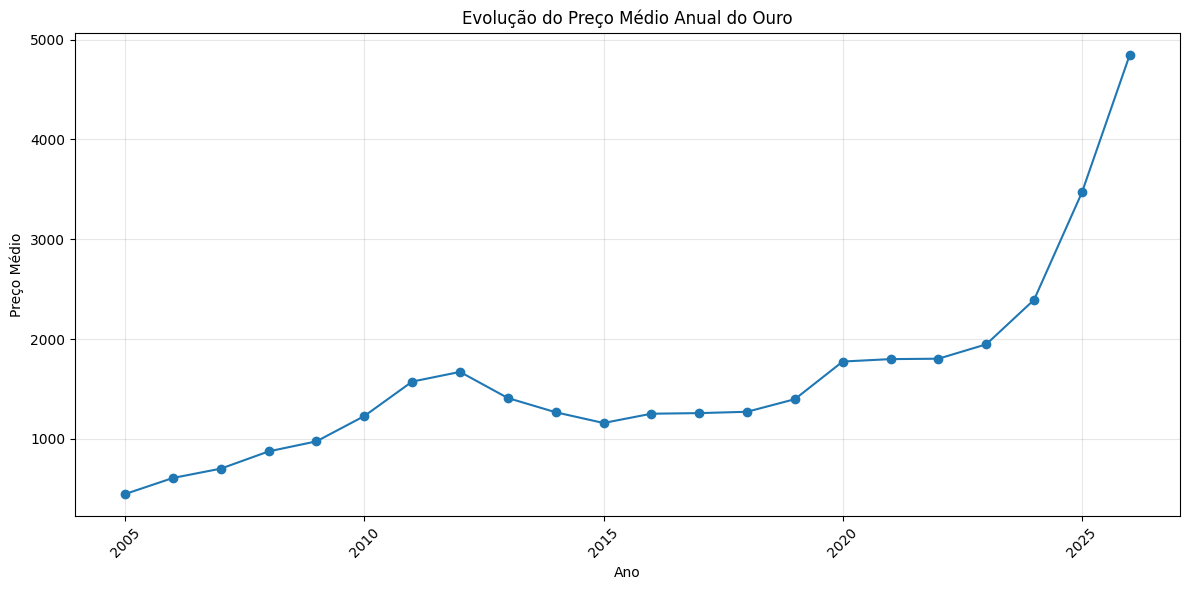

In [0]:
import matplotlib.pyplot as plt

# Preparar os dados para o gráfico
df_plot = (
    df_analysis_yearly
    .select("year", "average_price")
    .orderBy("year")
    .toPandas()
)

# Gráfico da evolução do preço médio anual
plt.figure(figsize=(12, 6))
plt.plot(
    df_plot["year"],
    df_plot["average_price"],
    marker="o"
)

plt.title("Evolução do Preço Médio Anual do Ouro")
plt.xlabel("Ano")
plt.ylabel("Preço Médio")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Retorno anual

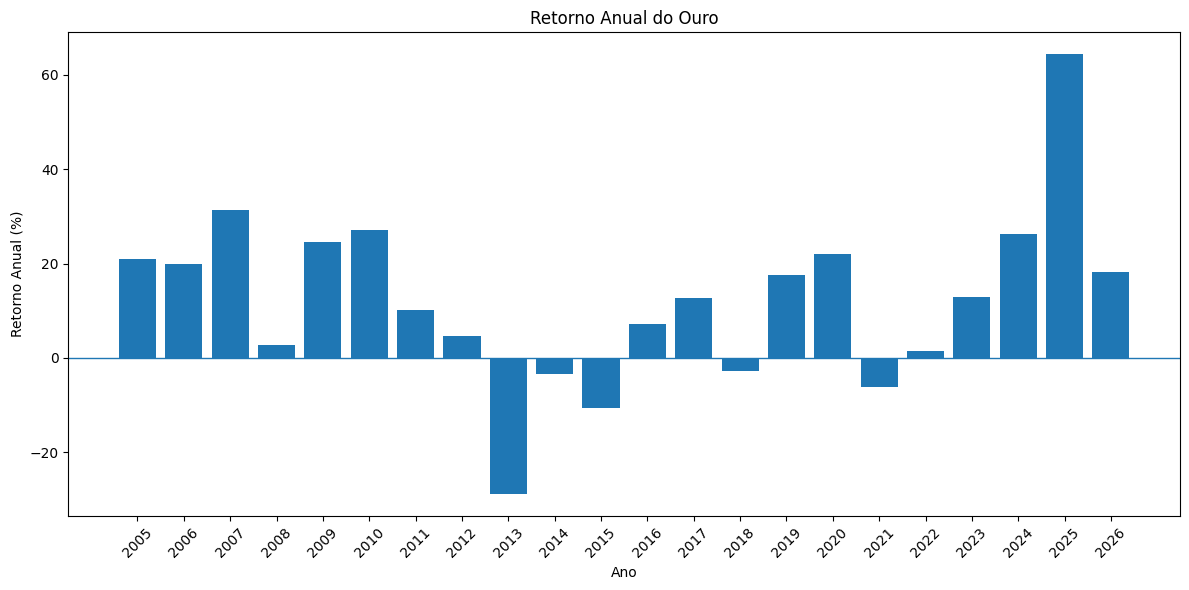

In [0]:
import matplotlib.pyplot as plt

# Preparar os dados para o gráfico
df_plot = (
    df_analysis_yearly
    .select("year", "annual_return_pct")
    .orderBy("year")
    .toPandas()
)

# Gráfico do retorno anual
plt.figure(figsize=(12, 6))

plt.bar(
    df_plot["year"].astype(str),
    df_plot["annual_return_pct"]
)

plt.title("Retorno Anual do Ouro")
plt.xlabel("Ano")
plt.ylabel("Retorno Anual (%)")
plt.axhline(y=0, linewidth=1)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

O maior retorno anual observado foi em 2025 (+64,34%), enquanto o menor ocorreu em 2013 (−28,81%). O ano de 2026 apresenta +18,26% até 24/02/2026, portanto não é comparável diretamente com anos completos.

Volatilidade

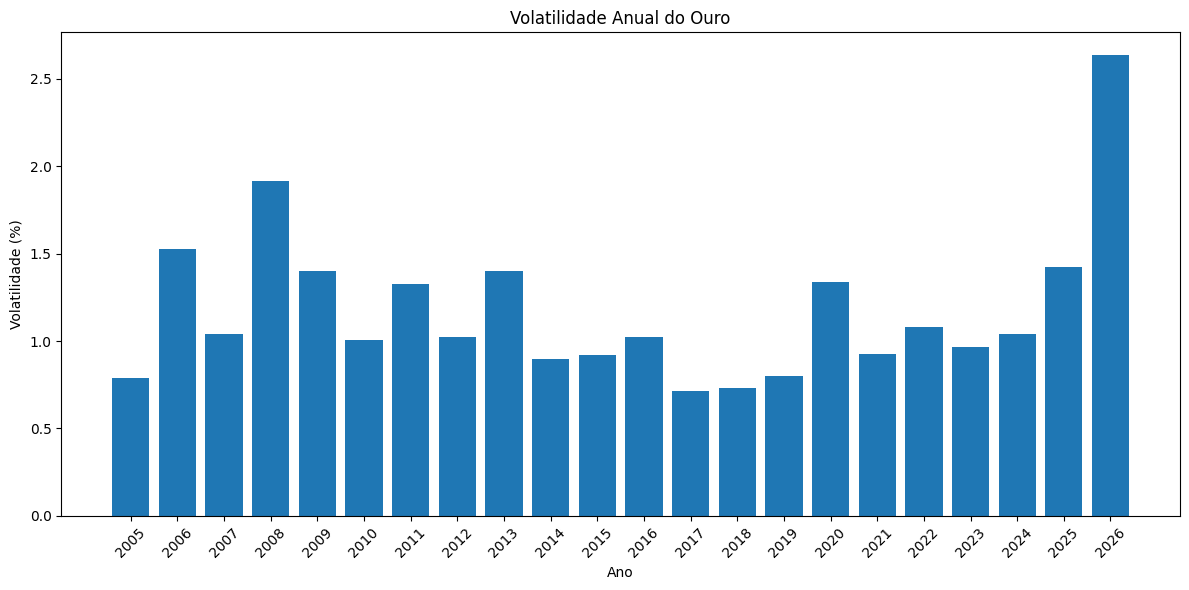

In [0]:
import matplotlib.pyplot as plt

# Preparar os dados para o gráfico
df_plot = (
    df_analysis_yearly
    .select("year", "volatility_pct")
    .orderBy("year")
    .toPandas()
)

# Gráfico da volatilidade anual
plt.figure(figsize=(12, 6))

plt.bar(
    df_plot["year"].astype(str),
    df_plot["volatility_pct"]
)

plt.title("Volatilidade Anual do Ouro")
plt.xlabel("Ano")
plt.ylabel("Volatilidade (%)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Conclusões

### 1. Como o preço evoluiu?

O preço médio anual apresentou uma tendência geral de crescimento ao longo do período analisado, apesar de algumas oscilações relevantes. Observa-se uma queda entre 2013 e 2015 e, posteriormente, uma retomada da trajetória de alta, com aceleração especialmente significativa em 2024 e 2025.

### 2. Quais períodos apresentaram maior volatilidade?

Considerando o desvio-padrão dos retornos diários (`annual_volatility_pct`), 2026 apresentou a maior volatilidade da série, de 2,63%. Entretanto, esse resultado deve ser interpretado com cautela, pois o ano possui apenas 39 pregões e representa um período parcial.

Entre os anos completos, 2008 apresentou a maior volatilidade, com 1,92%, seguido por 2006 (1,52%), 2025 (1,42%), 2013 (1,40%) e 2009 (1,40%).

### 3. Quais anos apresentaram maior e menor retorno?

Considerando o retorno calculado a partir do primeiro e do último preço observado em cada ano (`annual_return_pct`), 2025 apresentou o maior retorno da série, de +64,34%, enquanto 2013 apresentou o menor, de −28,81%.

2026 apresentou retorno de +18,26%, porém, por representar apenas parte do ano, esse resultado não deve ser comparado diretamente com os anos completos.

### 4. Existem problemas de qualidade que poderiam afetar as análises?

Foram identificados 4 registros com pequenas inconsistências nas relações entre abertura, máxima, mínima e preço de fechamento. Não foram identificados valores nulos, datas duplicadas ou preços negativos.

Os registros inconsistentes foram preservados, sem alteração ou exclusão dos valores originais, e as ocorrências foram documentadas como problemas presentes na fonte de dados. Essa decisão mantém a rastreabilidade dos dados e evita introduzir alterações não justificadas no dataset original.